# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HimanshuSharma-2856/Flyrank-ml--internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

This queue ranks the **client-grouped holdout only**: six clients were kept out of training, using the same seed, split, and full-snapshot baseline calculation as the W06 validation audit. It is an out-of-sample review exercise, not a complete live-site queue. The priority score is `70% model probability + 30% baseline score`, scaled to 0–100. It is a sorting aid, not a calibrated chance of business value.

| Reason code | What it means | Human next step |
|---|---|---|
| `model_decline_risk` | Grouped-holdout model probability is at least 0.65; this is a triage threshold, not a validated operating threshold. | Check the current page and trend evidence. |
| `stale_and_visible` | At least 180 days since update and at least 500 trailing-90-day impressions. | Check whether the page is still relevant and whether a substantive update is warranted. |
| `visible_low_ctr` | At least 500 impressions, observed position 1–20, and CTR below 0.5% (the stored `ctr` scale is percent). | Review query intent and the search snippet; do not rewrite from CTR alone. |
| `engagement_review` | At least 30 sessions and engagement or scroll rate below 30%. | Inspect page experience and measurement coverage. |
| `no_strong_signal` | None of the explicit review rules fired. | Monitor or gather better evidence; do not treat this as a healthy-page verdict. |

**Rule-based archetype → action mapping:** model-risk + low-CTR pages go to `review_snippet_and_search_intent`; model-risk + low-engagement pages go to `review_content_experience`; other model-risk or stale-visible pages go to `refresh_fact_check_and_prioritize`; CTR-only pages go to `audit_snippet_and_position`; engagement-only pages go to `review_page_experience`; no-strong-signal pages go to `monitor_or_measure`. If multiple rules fire, the most specific model-risk combination takes precedence. The archetype is a transparent combination of observable flags, not a discovered semantic cluster. Ties are ordered by trailing impressions. `confidence` is a descriptive priority-score band only.

**Cost/value:** no editorial labor cost, conversion value, or incremental refresh effect is measured here, so neither the score nor a reason code is ROI. Bound effort with a reviewer-set batch (for example, the top 50), start with low-cost checks such as intent/snippet review, and record minutes spent plus accept/reject/override. Only a later time-forward comparison or controlled pilot can assess whether deeper refresh work is worth its cost.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
here = Path.cwd()
candidates = [here, *here.parents, Path("/workspaces/Flyrank-ml-internship"), Path("/workspace")]
root_matches = [path for path in candidates if (path / "data" / "raw" / "content_refresh_anonymized.csv").exists()]
if not root_matches:
    local_matches = Path.home().glob("Downloads/**/data/raw/content_refresh_anonymized.csv")
    root_matches = [data_path.parents[2] for data_path in local_matches]
if not root_matches:
    raise FileNotFoundError(f"Could not locate the repository data from notebook cwd: {here}")
ROOT = root_matches[0]
DATA_PATH = ROOT / "data" / "raw" / "content_refresh_anonymized.csv"
OUTPUT_DIR = ROOT / "work" / "outputs"
FIGURE_DIR = ROOT / "work" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

raw = pd.read_csv(DATA_PATH)
raw["is_declining_label"] = raw["trend_direction"].fillna("").str.lower().eq("down").astype(int)
for column in raw.select_dtypes(include=["number"]).columns:
    raw[column] = raw[column].replace([np.inf, -np.inf], np.nan)

numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count", "impressions_90d",
    "clicks_90d", "sessions_90d", "ai_sessions_90d", "days_with_impressions", "days_with_sessions",
    "content_age_days", "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct",
]
categorical_features = [
    "competition_level", "content_type", "main_intent", "age_tier", "freshness_tier",
    "word_count_tier", "impression_tier", "position_tier",
]
numeric_features = [column for column in numeric_features if column in raw.columns]
categorical_features = [column for column in categorical_features if column in raw.columns]
feature_columns = numeric_features + categorical_features
forbidden_features = {
    "trend_direction", "trend_pct", "is_declining_label", "content_id", "client_id",
    "baseline_score", "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
}
assert feature_columns and not forbidden_features.intersection(feature_columns)

def percentile_score(series):
    numeric = pd.to_numeric(series, errors="coerce").fillna(0)
    return numeric.rank(method="average", pct=True)

def baseline_score(frame):
    impressions = percentile_score(np.log1p(frame["impressions_90d"]))
    freshness = percentile_score(frame["days_since_last_update"])
    avg_position = frame["avg_position"].fillna(0)
    position = (1 - avg_position.clip(lower=1, upper=50).rank(pct=True)) * impressions * (avg_position > 0)
    depth = (1 - percentile_score(frame["word_count"])) * impressions
    return (0.40 * impressions + 0.30 * freshness + 0.25 * position + 0.05 * depth).clip(0, 1)

raw["baseline_score"] = baseline_score(raw)
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median", add_indicator=True), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_leaf=25,
        class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE,
    )),
])

all_indices = np.arange(len(raw))
clients = raw["client_id"].fillna("unknown").astype(str).drop_duplicates().to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
test_clients = set(rng.permutation(clients)[:max(1, round(len(clients) * 0.20))])
group_test_mask = raw["client_id"].fillna("unknown").astype(str).isin(test_clients).to_numpy()
train_indices = all_indices[~group_test_mask]
test_indices = all_indices[group_test_mask]
train_frame = raw.iloc[train_indices]
test_frame = raw.iloc[test_indices].copy()
assert set(train_frame["client_id"]).isdisjoint(set(test_frame["client_id"]))

test_frame["baseline_score"] = raw.iloc[test_indices]["baseline_score"].to_numpy()
model.fit(train_frame[feature_columns], train_frame["is_declining_label"])
test_frame["model_probability"] = model.predict_proba(test_frame[feature_columns])[:, 1]
test_frame["priority_score"] = 100 * (
    0.70 * test_frame["model_probability"] + 0.30 * test_frame["baseline_score"]
)

def make_reason_codes(row):
    reasons = []
    if row["model_probability"] >= 0.65:
        reasons.append("model_decline_risk")
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        reasons.append("stale_and_visible")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        reasons.append("visible_low_ctr")
    weak_engagement = (
        (0 < row["engagement_rate"] < 30) or (0 < row["scroll_rate"] < 30)
    )
    if row["sessions_90d"] >= 30 and weak_engagement:
        reasons.append("engagement_review")
    return reasons or ["no_strong_signal"]

def map_action(reasons):
    reason_set = set(reasons)
    if "model_decline_risk" in reason_set and "visible_low_ctr" in reason_set:
        return "review_snippet_and_search_intent"
    if "model_decline_risk" in reason_set and "engagement_review" in reason_set:
        return "review_content_experience"
    if "model_decline_risk" in reason_set or "stale_and_visible" in reason_set:
        return "refresh_fact_check_and_prioritize"
    if "visible_low_ctr" in reason_set:
        return "audit_snippet_and_position"
    if "engagement_review" in reason_set:
        return "review_page_experience"
    return "monitor_or_measure"

test_frame["reason_codes"] = test_frame.apply(make_reason_codes, axis=1)
test_frame["review_archetype"] = test_frame["reason_codes"].map(
    lambda reasons: " + ".join(reason for reason in reasons if reason != "no_strong_signal") or "low_signal_monitor"
)
test_frame["suggested_action"] = test_frame["reason_codes"].map(map_action)
test_frame["reason_codes"] = test_frame["reason_codes"].map("|".join)

queue_columns = [
    "content_id", "priority_score", "model_probability", "baseline_score", "review_archetype",
    "suggested_action", "reason_codes", "content_type", "main_intent", "content_age_days",
    "days_since_last_update", "impressions_90d", "clicks_90d", "sessions_90d", "ctr", "avg_position",
]
queue = test_frame[queue_columns].sort_values(
    ["priority_score", "impressions_90d"], ascending=[False, False]
).reset_index(drop=True)
queue.insert(0, "rank", np.arange(1, len(queue) + 1))
queue["confidence"] = pd.cut(
    queue["priority_score"], [-np.inf, 40, 65, np.inf], labels=["low", "medium", "high"]
).astype(str)
queue["priority_score"] = queue["priority_score"].round(3)
queue["model_probability"] = queue["model_probability"].round(4)
queue["baseline_score"] = queue["baseline_score"].round(4)

labels = test_frame["is_declining_label"].to_numpy()
model_scores = test_frame["model_probability"].to_numpy()
precision_at_50 = float(labels[np.argsort(model_scores)[::-1][:min(50, len(labels))]].mean())
base_rate = float(labels.mean())
ap_score = float(average_precision_score(labels, model_scores))
print(f"Rows in grouped holdout: {len(queue):,}; held-out clients: {len(test_clients)}")
print(f"Holdout base rate: {base_rate:.3f}; model Precision@50: {precision_at_50:.3f}; average precision: {ap_score:.3f}")
print(f"Ranked actions prepared: {len(queue):,}; client overlap: {set(train_frame['client_id']).intersection(set(test_frame['client_id']))}")
print("Leakage guard: PASS; IDs and label-derived / overlapping-window fields are excluded from model features.")

Rows in grouped holdout: 2,325; held-out clients: 6
Holdout base rate: 0.391; model Precision@50: 0.660; average precision: 0.610
Ranked actions prepared: 2,325; client overlap: set()
Leakage guard: PASS; IDs and label-derived / overlapping-window fields are excluded from model features.


## 2. Intended use and limits

**Intended user:** a content operations lead or editor planning a small, time-boxed portfolio review. Use the queue to choose which pages to inspect first, then combine its reason codes with current editorial, search-intent, technical, and business context. The output is decision support for a supervised pilot, not an unattended workflow.

The model was fit on other clients and scored on the W06-style grouped holdout. In this run, the holdout contains **2,325 rows across six clients**, its declining-label base rate is **0.391**, model Precision@50 is **0.660**, and average precision is **0.610**. These are measured values for this starter snapshot and split; they are not expected performance on future clients or months. The group split addresses client overlap, but not time: trailing-90-day features overlap the 30-day label construction window. The label itself comes from `trend_direction`. That prevents a clean time-forward or causal refresh claim.

The queue omits the label, client ID, title, URL, and query data. Pseudonymous `content_id` is included only to join a row back inside the approved local review workflow; never use it as a feature or try to re-identify it. The prioritization blend, reason thresholds, confidence bands, and actions are practical hypotheses, not calibrated probabilities, costs, or experimentally proven interventions.

In [9]:
evaluation_summary = {
    "rows_scored": int(len(queue)),
    "held_out_clients": int(len(test_clients)),
    "client_overlap": len(set(train_frame["client_id"]).intersection(set(test_frame["client_id"]))),
    "holdout_base_rate": base_rate,
    "model_precision_at_50": precision_at_50,
    "model_average_precision": ap_score,
    "target": "is_declining_label derived from trend_direction",
    "feature_window_caveat": "trailing-90-day features overlap the 30-day label construction window",
}
assert evaluation_summary["client_overlap"] == 0
assert evaluation_summary["rows_scored"] == len(test_indices)
assert "is_declining_label" not in queue.columns
assert "client_id" not in queue.columns
print(pd.Series(evaluation_summary).to_string())

rows_scored                                                             2325
held_out_clients                                                           6
client_overlap                                                             0
holdout_base_rate                                                   0.390968
model_precision_at_50                                                   0.66
model_average_precision                                             0.609547
target                       is_declining_label derived from trend_direction
feature_window_caveat      trailing-90-day features overlap the 30-day la...


## 3. Human review + the no-go list

A person must review **every** row before work is scheduled. For a proposed refresh, verify the live page and its current status, the intended audience and search intent, factual accuracy and source freshness, recent edits, indexing/canonical/redirect state, and whether another page already serves the same intent. Compare the recommendation with like content types; inspect the underlying measurements and known missingness. Record accept, reject, or override plus a short reason and reviewer. A missing/zero position or weak measurement coverage lowers confidence; it is not evidence of no opportunity.

The action labels are review tasks, not instructions to publish. **Never automate:** writing or rewriting copy, changing titles/snippets, publishing, deleting, redirecting, changing canonical/indexing settings, changing client strategy or budget, or representing a score as a traffic/ranking guarantee. Do not infer what a search engine will do, identify a client from a pseudonym, or send pseudonymous IDs or row-level data to an unapproved external service. This is a local, non-production review aid only.

In [10]:
archetype_action_map = (
    queue.groupby("review_archetype", as_index=False)
    .agg(
        suggested_action=("suggested_action", "first"),
        distinct_actions=("suggested_action", "nunique"),
        queue_rows=("rank", "size"),
    )
    .sort_values(["queue_rows", "review_archetype"], ascending=[False, True])
)
allowed_actions = {
    "review_snippet_and_search_intent",
    "review_content_experience",
    "refresh_fact_check_and_prioritize",
    "audit_snippet_and_position",
    "review_page_experience",
    "monitor_or_measure",
}
no_go_actions = {"auto_rewrite", "auto_publish", "auto_delete", "auto_redirect"}
assert archetype_action_map["distinct_actions"].eq(1).all()
assert set(queue["suggested_action"]).issubset(allowed_actions)
assert not set(queue["suggested_action"]).intersection(no_go_actions)
assert not queue["suggested_action"].str.startswith("auto_").any()
print("Observed archetype -> action mapping (every row still requires review):")
print(archetype_action_map.to_string(index=False))
print("\nHuman-review policy checks: PASS; no automated edit, publish, delete, or redirect action exists.")

Observed archetype -> action mapping (every row still requires review):
                                        review_archetype                  suggested_action  distinct_actions  queue_rows
                                      low_signal_monitor                monitor_or_measure                 1        1650
                    model_decline_risk + visible_low_ctr  review_snippet_and_search_intent                 1         209
                                      model_decline_risk refresh_fact_check_and_prioritize                 1         187
                                         visible_low_ctr        audit_snippet_and_position                 1         143
                     visible_low_ctr + engagement_review        audit_snippet_and_position                 1          69
                                       engagement_review            review_page_experience                 1          47
model_decline_risk + visible_low_ctr + engagement_review  review_snippet_and_sear

## 4. Monitoring / retrain triggers

For a small, non-production pilot, review the queue once per monthly snapshot and sample the top 50 decisions with an editor. Track accept/reject/override reasons, action mix, required-field coverage by content type, label prevalence, and (only after labels mature) time-forward Precision@50 against the simple baseline. The update-age table below compares different pages in one snapshot; it is not a longitudinal decay curve and does not show refresh impact.

These are **proposed guardrails**, not thresholds validated by this experiment:

- Pause and investigate if any required input is absent, or required-feature missingness shifts by 5 percentage points or more from the pilot reference.
- Recheck the rules and source data if the action mix shifts by 25% or more relative to the previous monthly snapshot, after accounting for portfolio composition.
- Do not retrain on the same holdout. Consider retraining only after new labels mature in a genuinely time-forward cohort; investigate and recalibrate only if model Precision@50 is below the baseline in two consecutive monthly cohorts, or target/feature definitions change.
- If labels are not available on a time-forward basis, monitor data quality and human overrides only. Do not present those checks as model-performance validation.

In [11]:
decay_frame = raw.loc[pd.to_numeric(raw["days_since_last_update"], errors="coerce").ge(0)].copy()
decay_frame["update_age_bucket"] = pd.cut(
    decay_frame["days_since_last_update"],
    bins=[-1, 90, 180, 365, np.inf],
    labels=["0-90 days", "91-180 days", "181-365 days", "366+ days"],
)
decay_summary = (
    decay_frame.groupby("update_age_bucket", observed=False)
    .agg(
        rows=("content_id", "size"),
        median_impressions_90d=("impressions_90d", "median"),
        median_clicks_90d=("clicks_90d", "median"),
    )
    .reset_index()
)
observed_buckets = decay_summary.loc[decay_summary["rows"].gt(0)].copy()
assert observed_buckets["rows"].sum() == len(decay_frame)
print("Update-age buckets in the starter snapshot (descriptive, not causal):")
print(observed_buckets.to_string(index=False))
if len(observed_buckets) >= 2:
    first = observed_buckets.iloc[0]
    last = observed_buckets.iloc[-1]
    direction = "higher" if last["median_impressions_90d"] > first["median_impressions_90d"] else "lower or equal"
    print(
        f"\nOldest-bucket median impressions are {direction} than the newest bucket "
        f"({last['median_impressions_90d']:.0f} vs {first['median_impressions_90d']:.0f}). "
        "This is a between-page snapshot comparison; it cannot establish temporal decay or refresh effect."
    )

monitoring_triggers = {
    "cadence": "monthly snapshot; human sample of the top 50",
    "pause_if_required_input_missing": True,
    "investigate_feature_missingness_shift_pp": 5,
    "investigate_action_mix_relative_shift_pct": 25,
    "consider_retraining_only_after": "matured time-forward labels; below-baseline Precision@50 in two consecutive cohorts, or changed target/features",
}
print("\nMonitoring guardrails (proposed, not empirically tuned):")
print(pd.Series(monitoring_triggers).to_string())

Update-age buckets in the starter snapshot (descriptive, not causal):
update_age_bucket  rows  median_impressions_90d  median_clicks_90d
        0-90 days 20655                   472.0                1.0
      91-180 days  9171                  1692.0                2.0
     181-365 days   169                    16.0                0.0
        366+ days     5                     2.0                0.0

Oldest-bucket median impressions are lower or equal than the newest bucket (2 vs 472). This is a between-page snapshot comparison; it cannot establish temporal decay or refresh effect.

Monitoring guardrails (proposed, not empirically tuned):
cadence                                           monthly snapshot; human sample of the top 50
pause_if_required_input_missing                                                           True
investigate_feature_missingness_shift_pp                                                     5
investigate_action_mix_relative_shift_pct                         

## 5. Exports for the paper

The notebook writes the **grouped-holdout ranked queue** to `work/outputs/w07_ranked_action_queue.csv`. The queue is deliberately gitignored because it contains row-level pseudonymous IDs; regenerate it locally and do not commit it. It writes aggregate evidence and reproducibility details to `work/outputs/w07_playbook_metrics.json`; keep this JSON committed as the paper's metrics receipt. The update-age figure is written to `work/outputs/` and the reusable, committed copy to `work/figures/`. No client IDs, titles, URLs, or queries are exported.

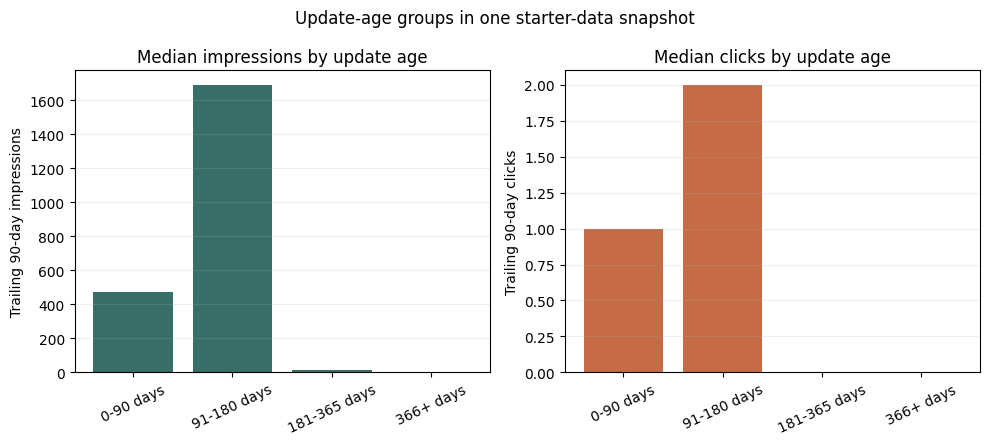

Wrote ranked queue: C:\Users\Himanshu\Downloads\flyrank-ml-internship-main\flyrank-ml-internship-main\work\outputs\w07_ranked_action_queue.csv (2,325 rows; do not commit this CSV)
Wrote committed metrics receipt: C:\Users\Himanshu\Downloads\flyrank-ml-internship-main\flyrank-ml-internship-main\work\outputs\w07_playbook_metrics.json
Wrote paper figure: C:\Users\Himanshu\Downloads\flyrank-ml-internship-main\flyrank-ml-internship-main\work\outputs\w07_update_age_visibility.png and C:\Users\Himanshu\Downloads\flyrank-ml-internship-main\flyrank-ml-internship-main\work\figures\w07_update_age_visibility.png
Holdout Precision@50: model=0.660; baseline=0.280; base rate=0.391


In [12]:
import json

import matplotlib.pyplot as plt

queue_path = OUTPUT_DIR / "w07_ranked_action_queue.csv"
metrics_path = OUTPUT_DIR / "w07_playbook_metrics.json"
figure_output_path = OUTPUT_DIR / "w07_update_age_visibility.png"
figure_commit_path = FIGURE_DIR / "w07_update_age_visibility.png"

baseline_order = np.argsort(test_frame["baseline_score"].to_numpy())[::-1][:min(50, len(test_frame))]
baseline_precision_at_50 = float(labels[baseline_order].mean())
action_counts = queue["suggested_action"].value_counts().sort_index()
reason_counts = {}
for codes in queue["reason_codes"]:
    for code in codes.split("|"):
        reason_counts[code] = reason_counts.get(code, 0) + 1

figure_data = observed_buckets.copy()
figure_labels = figure_data["update_age_bucket"].astype(str).tolist()
figure_counts = figure_data["rows"].astype(int).tolist()
figure_impressions = figure_data["median_impressions_90d"].astype(float).tolist()
figure_clicks = figure_data["median_clicks_90d"].astype(float).tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(figure_labels, figure_impressions, color="#376f68")
axes[0].set_title("Median impressions by update age")
axes[0].set_ylabel("Trailing 90-day impressions")
axes[1].bar(figure_labels, figure_clicks, color="#c56b45")
axes[1].set_title("Median clicks by update age")
axes[1].set_ylabel("Trailing 90-day clicks")
for axis in axes:
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.2)
fig.suptitle("Update-age groups in one starter-data snapshot")
fig.tight_layout()
fig.savefig(figure_output_path, dpi=180, bbox_inches="tight")
fig.savefig(figure_commit_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

queue.to_csv(queue_path, index=False)
metrics_payload = {
    "artifact": "ML-10 content action playbook",
    "source": "data/raw/content_refresh_anonymized.csv",
    "random_state": RANDOM_STATE,
    "validation_design": "20% client-grouped holdout; queue contains held-out rows only",
    "train_rows": int(len(train_frame)),
    "queue_rows": int(len(queue)),
    "held_out_client_count": int(len(test_clients)),
    "client_overlap": int(evaluation_summary["client_overlap"]),
    "target": "is_declining_label derived from trend_direction",
    "holdout_base_rate": base_rate,
    "model_precision_at_50": precision_at_50,
    "baseline_precision_at_50": baseline_precision_at_50,
    "model_average_precision": ap_score,
    "precision_at_50_lift_over_base_rate": precision_at_50 - base_rate,
    "priority_score": "100 * (0.70 * model_probability + 0.30 * baseline_score)",
    "reason_thresholds": {
        "model_decline_risk_probability": 0.65,
        "stale_and_visible_days_since_update": 180,
        "stale_and_visible_impressions_90d": 500,
        "visible_low_ctr_impressions_90d": 500,
        "visible_low_ctr_position_max": 20,
        "visible_low_ctr_ctr_percent_max_exclusive": 0.5,
        "engagement_review_sessions_90d": 30,
        "engagement_review_rate_percent_max_exclusive": 30,
    },
    "action_counts": {str(key): int(value) for key, value in action_counts.items()},
    "reason_code_counts": {str(key): int(value) for key, value in sorted(reason_counts.items())},
    "update_age_snapshot": [
        {
            "bucket": str(row.update_age_bucket),
            "rows": int(row.rows),
            "median_impressions_90d": float(row.median_impressions_90d),
            "median_clicks_90d": float(row.median_clicks_90d),
        }
        for row in observed_buckets.itertuples(index=False)
    ],
    "limits": [
        "90-day features overlap the 30-day label construction window; no clean time-forward claim.",
        "Cross-sectional update-age differences do not establish decay or refresh impact.",
        "Reason and priority thresholds are uncalibrated decision-support heuristics.",
        "Every action requires human review; no content change is automated.",
    ],
    "outputs": {
        "ranked_queue_csv": "work/outputs/w07_ranked_action_queue.csv (gitignored; regenerate locally)",
        "metrics_json": "work/outputs/w07_playbook_metrics.json",
        "figure_output": "work/outputs/w07_update_age_visibility.png",
        "figure_committed": "work/figures/w07_update_age_visibility.png",
    },
}
with metrics_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics_payload, metrics_file, indent=2, ensure_ascii=True)

assert queue_path.exists() and queue_path.stat().st_size > 0
assert metrics_path.exists() and metrics_path.stat().st_size > 0
assert figure_output_path.exists() and figure_commit_path.exists()
assert "client_id" not in queue.columns and "is_declining_label" not in queue.columns
assert "trend_direction" not in queue.columns and "trend_pct" not in queue.columns
print(f"Wrote ranked queue: {queue_path} ({len(queue):,} rows; do not commit this CSV)")
print(f"Wrote committed metrics receipt: {metrics_path}")
print(f"Wrote paper figure: {figure_output_path} and {figure_commit_path}")
print(f"Holdout Precision@50: model={precision_at_50:.3f}; baseline={baseline_precision_at_50:.3f}; base rate={base_rate:.3f}")

## Self-check

- [x] Sections 1–5 explain ranked actions, reason codes, intended use, limits, human review, no-go cases, monitoring, cost/value, decay evidence, and exports.
- [x] Notebook executed top to bottom; the final cell checks the queue and paper artifacts.
- [x] No client names, URLs, titles, or private queries are present in the exports.
- [x] Claims are descriptive and decision-support only; no causal refresh claim is made.
- [x] Queue CSV is local and uncommitted; metrics JSON and reusable figure were generated.
- [ ] Commit the executed notebook, metrics JSON, and figure from a Git checkout. This workspace mount has no `.git` metadata.

In [14]:
import json

metrics_on_disk = json.loads(metrics_path.read_text(encoding="utf-8"))
exported_queue = pd.read_csv(queue_path)
assert len(exported_queue) == len(queue) == len(test_indices)
assert exported_queue["rank"].tolist() == list(range(1, len(exported_queue) + 1))
assert np.diff(exported_queue["priority_score"].to_numpy()).max(initial=0) <= 0
assert exported_queue["content_id"].is_unique
assert not {"client_id", "is_declining_label", "trend_direction", "trend_pct"}.intersection(exported_queue.columns)
assert set(exported_queue["suggested_action"]).issubset(allowed_actions)
assert metrics_on_disk["client_overlap"] == 0
assert metrics_on_disk["queue_rows"] == len(exported_queue)
assert metrics_on_disk["model_precision_at_50"] == precision_at_50
assert metrics_path.exists() and figure_output_path.exists() and figure_commit_path.exists()
contains_url = exported_queue.astype("string").apply(
    lambda column: column.str.contains(r"https?://", regex=True, na=False)
).any().any()
assert not contains_url
print("SELF-CHECK: PASS")
print(f"Queue: {len(exported_queue):,} unique ranked rows; actions={exported_queue['suggested_action'].nunique()}")
print(f"Metrics: model P@50={metrics_on_disk['model_precision_at_50']:.3f}; baseline P@50={metrics_on_disk['baseline_precision_at_50']:.3f}; base rate={metrics_on_disk['holdout_base_rate']:.3f}")
print("Privacy/export checks: PASS; row-level client IDs, labels, trend fields, and URLs are absent.")
print(f"Artifacts: {queue_path.name}, {metrics_path.name}, {figure_commit_path.name}")

SELF-CHECK: PASS
Queue: 2,325 unique ranked rows; actions=6
Metrics: model P@50=0.660; baseline P@50=0.280; base rate=0.391
Privacy/export checks: PASS; row-level client IDs, labels, trend fields, and URLs are absent.
Artifacts: w07_ranked_action_queue.csv, w07_playbook_metrics.json, w07_update_age_visibility.png
